# Where Does the Probe Fire? - Token-Level Interpretation

`experiment.ipynb` trained a difference-of-means probe (layer 28, Qwen3-14B) on **mean-pooled**
completion activations and found strong held-out separation (test AUROC 0.9308), but also flagged
an unresolved confound: positive-labeled completions hit the `max_new_tokens` budget substantially
more often than negative ones, so part of that separation could reflect "this trajectory is still
mid-generation" rather than step-3 content specifically.

This notebook doesn't retrain anything. It reuses the saved probe and the trajectories already
generated and cached in `outputs/train` and `outputs/test`, and asks a different question of the
same data: instead of one pooled score per trajectory, what does the probe's score look like
**token by token** across a trajectory? If the probe is tracking a genuine, discrete step-3 event
(extract entropy, transform it, compare to threshold, decide), we'd expect to see localized peaks
around that moment - not a uniform elevation smeared across the whole completion (which would be
more consistent with a topic-level or length/completeness confound).

**Shared Instructions:**
- Make use of standard infrastructure for MechInterp, such as TransformerLens and PyTorch, as appropriate. Don't do extra work where ready-made solutions are mature and fit well.
- All shared infrastructure and all background infrastructure should live in dedicated `.py` files, not in notebooks. Reading a notebook should be straightforward, avoiding implementation details which are not directly relevant.
  - Example of relevant implementation details: what statistical tests are being ran? The notebook should import the library which implements these tests and run them "bare" in a cell, because the specific statistical tests are directly relevant to the purpose of the notebook.
  - Example of irrelevant implementation details: how are prompts loaded? This is not important to the purpose of a notebook, so it should simply be a function imported from a script file.
- **No Pandas**. Results are kept as tensors and lists/dicts of tensors. Indices are simplified and avoid unnecessary rekeying. There are no DataFrames in this notebook.
- **Use SIZES**. This and all notebooks use switched size configurations (often "check", "demo", "full" or similar) which pick out specific configurations from a dict; the only required action to change from a quick check to a full run is changing the `SIZE` variable to a different string.
- Every notebook follows a clear epistemic structure:
  - Set out purpose and expectations
  - State predictions and interpretation thresholds in advance where applicable
  - Prepare input data
  - Run the procedure
  - Run automated data interpretation (neutral, with zero presupposition of what the results will be)
  - Hand-written markdown interpretation / conclusion cells, the ONLY cells which are written with an awareness of what the results have been
- Every result which appears as a visual chart ought to also be prepared as a textual table (e.g. display some markdown).

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from IPython.display import HTML, display

from utilities import (
    load_model,
    load_trajectories,
    load_probe,
    add_token_scores_batch,
    load_cached_token_scores,
    save_token_scores,
)

## Purpose and Expectations

### What we're testing

The probe direction and bias are fixed (loaded from `probes/diff_of_means_probe.pt`, fit in
`experiment.ipynb`); nothing here retrains or reselects them. For each already-generated
completion, this notebook re-runs one forward pass through the same model to get **per-token**
`resid_post` at the probe's layer, projects every token individually onto the probe direction
(`score_t = resid_post[t] @ direction - bias`), and looks at the resulting score curve.

### Why this matters for the truncation confound

If token-level peaks cluster around content that plausibly *is* step 3 (a stated random value, an
explicit comparison to the threshold, a rendered decision), that's evidence the probe tracks the
intended construct and the pooled-mean result isn't purely an artifact of completion length. If
instead positive trajectories just show a diffuse, roughly-uniform elevation with no distinguishable
peak - or peaks that occur equally whether or not the trajectory is near truncation - that would
weaken confidence that the pooled AUROC reflects genuine step-3 detection rather than something
more diffuse or confound-driven.

## Predictions

Set out before looking at any token-level scores or text:

1. **Positive trajectories should be spikier than negative trajectories.** If the probe fires on a
   discrete step-3 event, positive completions should show higher peak prominence / higher score
   variance than negative completions, which have no such event to fire on and should look flatter.
2. **Peaks should land on content, not boilerplate.** Manually reading the highest peaks (via the
   token-highlighted text and peak-context exports below), we'd expect them to fall near numeric
   extraction, threshold comparison, or decision-rendering language - not on generic connective
   tokens, formatting, or the tail end of a trajectory regardless of content (which would instead
   suggest a length/position confound).
3. **The aggregate (mean) curve across positive trajectories should be *more* structured than flat**
   even after normalizing every trajectory to fractional position 0-1, e.g. a bump rather than a
   flat elevated line - though pooling many trajectories at different absolute lengths onto a
   normalized axis will smear out any peak that isn't at a consistent *relative* position, so a flat
   mean curve here is a weak signal at best (peaks could be real but not position-aligned across
   trajectories) - this is why the per-trajectory (not just aggregate) view matters too.

No AUROC-style pre-registered accept/reject threshold is set here - this is a qualitative,
descriptive follow-up, not a second hypothesis test.

In [3]:
SIZE = 'full'  # 'smoke' = tiny model + a random direction, pipeline plumbing check only, no signal expected; 'full' = real probe on Qwen3-14B

SIZES = {
    'smoke': {
        # Reuses a couple of already-generated (Qwen3-14B) completions, but scores them with a small
        # model and a random direction, purely to exercise every code path (batched per-token scoring,
        # peak detection, plotting, HTML highlighting, peak-context export) before spending real compute.
        'model_name': "Qwen/Qwen2.5-0.5B-Instruct",
        'use_real_probe': False,
        'n_positive_trajectories': 4,
        'n_negative_trajectories': 4,
        'block_size': 8,
        'context_before': 12,
        'context_after': 6,
        'n_highlight_each': 1,
    },
    'full': {
        'model_name': "Qwen/Qwen3-14B",
        'use_real_probe': True,
        'n_positive_trajectories': None,  # None = all available
        'n_negative_trajectories': None,
        'block_size': 32,
        'context_before': 24,
        'context_after': 12,
        'n_highlight_each': 3,
    },
}

config = SIZES[SIZE]
print(f"Running with SIZE={SIZE}")
print(f"Config: {config}")

Running with SIZE=full
Config: {'model_name': 'Qwen/Qwen3-14B', 'use_real_probe': True, 'n_positive_trajectories': None, 'n_negative_trajectories': None, 'block_size': 32, 'context_before': 24, 'context_after': 12, 'n_highlight_each': 3}


## Prepare Input Data

Loads the probe (real, for `SIZE='full'`; a random direction at a mid-ish layer of the small model,
for `SIZE='smoke'`) and a sample of already-generated, already-labeled trajectories from
`outputs/train` and `outputs/test` (both gitignored, both already on disk from `experiment.ipynb` -
nothing is regenerated here). No model forward passes happen until the next section.

In [4]:
if config['use_real_probe']:
    probe = load_probe()
    PROBE_LAYER = probe['layer']
    PROBE_DIRECTION = probe['direction']
    PROBE_BIAS = probe['bias']
    assert probe['model_name'] == config['model_name'], (probe['model_name'], config['model_name'])
    print(f"Loaded real probe: layer={PROBE_LAYER}, model={probe['model_name']}")
else:
    # Smoke mode: no probe exists for the small model, so use a fixed (seeded, reproducible) random
    # unit direction at a mid-ish layer purely to exercise the scoring/plotting/export code paths.
    rng = torch.Generator().manual_seed(0)
    D_MODEL_SMOKE = 896  # Qwen2.5-0.5B-Instruct hidden size
    PROBE_LAYER = 12
    PROBE_DIRECTION = torch.nn.functional.normalize(torch.randn(D_MODEL_SMOKE, generator=rng), dim=0)
    PROBE_BIAS = 0.0
    print(f"Smoke mode: synthetic random direction at layer={PROBE_LAYER}, d_model={D_MODEL_SMOKE}")

Loaded real probe: layer=28, model=Qwen/Qwen3-14B


In [5]:
def load_sample(out_dir, label, n):
    records = [r for r in load_trajectories(Path(out_dir)) if r['label'] == label]
    if n is not None:
        records = records[:n]
    return records

train_pos = load_sample('outputs/train', 'positive', config['n_positive_trajectories'])
train_neg = load_sample('outputs/train', 'negative', config['n_negative_trajectories'])
test_pos = load_sample('outputs/test', 'positive', config['n_positive_trajectories'])
test_neg = load_sample('outputs/test', 'negative', config['n_negative_trajectories'])

print(f"Loaded: {len(train_pos)} train-positive, {len(train_neg)} train-negative, "
      f"{len(test_pos)} test-positive, {len(test_neg)} test-negative")

Loaded: 200 train-positive, 200 train-negative, 50 test-positive, 50 test-negative


## Run the Procedure

Per-token scores are cached to disk (`outputs/token_scores/`, gitignored like the rest of
`outputs/`), tagged with the exact probe (model, layer, direction, bias) that produced them - see
`load_cached_token_scores`/`save_token_scores` in `utilities.py`. The cache is checked *before* the
model is loaded at all: rerunning this notebook for a downstream tweak (a plot, the color scale,
the peak-detection settings) costs nothing extra once every trajectory has been scored once for the
current probe. A model load and one HookedTransformer forward pass per batch (see
`add_token_scores_batch`) only happens for whatever isn't already cached, batched by (source, label)
group the same way `experiment.ipynb` batched activation caching.

In [6]:
groups = {
    'train_positive': train_pos,
    'train_negative': train_neg,
    'test_positive': test_pos,
    'test_negative': test_neg,
}

# Check the on-disk cache before paying for anything - not just before scoring, but before even
# loading the model. Records not found in cache (or cached under a different probe) are collected
# for the next cell to compute.
pending = {}
n_cached_total = 0
for name, records in groups.items():
    group_pending = []
    for r in records:
        cached = load_cached_token_scores(r, PROBE_DIRECTION, PROBE_BIAS, PROBE_LAYER, config['model_name'])
        if cached is not None:
            r['token_scores'], r['token_strs'] = cached
            n_cached_total += 1
        else:
            group_pending.append(r)
    pending[name] = group_pending

n_pending_total = sum(len(v) for v in pending.values())
print(f"{n_cached_total} trajectories loaded from cache, {n_pending_total} need scoring")

500 trajectories loaded from cache, 0 need scoring


In [7]:
model = None
if n_pending_total > 0:
    model = load_model(model_name=config['model_name'])
    print(f"Loaded {model.cfg.model_name} on {model.cfg.device}")
    print(f"n_layers={model.cfg.n_layers}, d_model={model.cfg.d_model}")
else:
    print("Everything was already cached - no model load needed.")

Everything was already cached - no model load needed.


In [8]:
# Sub-batch: scoring all trajectories in a group at once OOMs (attention-score memory scales with
# batch_size * seq_len^2). load_trajectories sorts by filename, so records within a group already
# fall into contiguous per-pair blocks - batch_size=10 matches experiment.ipynb's per-pair batching.
BATCH_SIZE = 10

for name, records in pending.items():
    for start in range(0, len(records), BATCH_SIZE):
        chunk = records[start:start + BATCH_SIZE]
        add_token_scores_batch(model, chunk, PROBE_DIRECTION, PROBE_BIAS, PROBE_LAYER)
        for r in chunk:
            save_token_scores(r, PROBE_DIRECTION, PROBE_BIAS, PROBE_LAYER, config['model_name'])
    print(f"Scored {len(records)} {name} trajectories" + (" (newly computed)" if records else " (all cached)"))

Scored 0 train_positive trajectories (all cached)
Scored 0 train_negative trajectories (all cached)
Scored 0 test_positive trajectories (all cached)
Scored 0 test_negative trajectories (all cached)


In [9]:
if model is not None:
    del model
    torch.cuda.empty_cache()

## Automated Data Interpretation

Everything below is computed from the `token_scores` / `token_strs` fields added above. No
trajectory text is read by a human until the token-highlighted and peak-context sections - the
peak-count and aggregate-curve statistics come first and are reported regardless of what they show.

### Peak detection (per trajectory)

Raw per-token scores are noisy token-to-token (individual `resid_post` vectors swing a lot on
punctuation/whitespace/subword boundaries), so peak-finding runs on a smoothed curve: a
`smooth_window`-token moving average, then `scipy.signal.find_peaks` with prominence >= 1.5
standard deviations of *that trajectory's own smoothed curve* (so "peak" is relative to the
trajectory's own scale) and a minimum separation between peaks (`distance`) scaled to trajectory
length, so nearby wiggles don't count as separate peaks. Reported/exported peaks are further capped
to the top `top_k` by height, so one noisy trajectory can't dominate the peak-context export.


In [10]:
SMOOTH_WINDOW = 5
TOP_K_PEAKS = 5

def trajectory_peaks(record, smooth_window=SMOOTH_WINDOW, top_k=TOP_K_PEAKS):
    scores = np.array(record['token_scores'])
    if len(scores) < smooth_window + 2:
        return np.array([], dtype=int), scores
    kernel = np.ones(smooth_window) / smooth_window
    smoothed = np.convolve(scores, kernel, mode='same')
    if smoothed.std() == 0:
        return np.array([], dtype=int), scores
    min_distance = max(5, len(scores) // 20)
    peak_idx, _ = find_peaks(smoothed, prominence=1.5 * smoothed.std(), distance=min_distance)
    if len(peak_idx) > top_k:
        top = np.argsort(smoothed[peak_idx])[::-1][:top_k]
        peak_idx = np.sort(peak_idx[top])
    return peak_idx, scores

def peak_summary(records):
    rows = []
    for r in records:
        peak_idx, scores = trajectory_peaks(r)
        if len(peak_idx) == 0:
            rows.append((r, 0, float(scores.max()) if len(scores) else float('nan'), float('nan')))
        else:
            best = peak_idx[np.argmax(scores[peak_idx])]
            rows.append((r, len(peak_idx), float(scores[best]), best / (len(scores) - 1)))
    return rows

print("Split       | Label    | Pair | Rep | Peaks | Top peak height | Top peak position")
print("------------|----------|------|-----|-------|------------------|-------------------")
all_rows = {}
for name, records in groups.items():
    rows = peak_summary(records)
    all_rows[name] = rows
    for r, n_peaks, top_height, top_pos in rows:
        pos_str = f"{top_pos:.2f}" if not np.isnan(top_pos) else "n/a"
        print(f"{name:11s} | {r['label']:8s} | {r['pair_index']:4d} | {r['replicate_index']:3d} "
              f"| {n_peaks:5d} | {top_height:16.3f} | {pos_str}")

Split       | Label    | Pair | Rep | Peaks | Top peak height | Top peak position
------------|----------|------|-----|-------|------------------|-------------------
train_positive | positive |    0 |   0 |     5 |          116.818 | 0.89
train_positive | positive |    0 |   1 |     5 |          123.272 | 0.75
train_positive | positive |    0 |   2 |     5 |          112.449 | 0.48
train_positive | positive |    0 |   3 |     5 |          146.826 | 0.35
train_positive | positive |    0 |   4 |     5 |          138.843 | 0.32
train_positive | positive |    0 |   5 |     5 |          123.031 | 0.41
train_positive | positive |    0 |   6 |     5 |          127.550 | 0.35
train_positive | positive |    0 |   7 |     5 |          120.801 | 0.73
train_positive | positive |    0 |   8 |     5 |          128.943 | 0.90
train_positive | positive |    0 |   9 |     5 |          154.170 | 0.73
train_positive | positive |    1 |   0 |     5 |          143.246 | 0.64
train_positive | positive |    

train_negative | negative |    0 |   0 |     5 |           55.393 | 0.68
train_negative | negative |    0 |   1 |     5 |           40.400 | 0.65
train_negative | negative |    0 |   2 |     5 |           41.901 | 0.60
train_negative | negative |    0 |   3 |     5 |           32.252 | 0.78
train_negative | negative |    0 |   4 |     5 |           41.338 | 0.57
train_negative | negative |    0 |   5 |     5 |           45.146 | 0.61
train_negative | negative |    0 |   6 |     5 |           55.387 | 0.06
train_negative | negative |    0 |   7 |     5 |           38.186 | 0.93
train_negative | negative |    0 |   8 |     5 |           45.500 | 0.79
train_negative | negative |    0 |   9 |     5 |           46.972 | 0.57
train_negative | negative |    1 |   0 |     5 |           62.354 | 0.75
train_negative | negative |    1 |   1 |     5 |           71.873 | 0.88
train_negative | negative |    1 |   2 |     4 |           52.657 | 0.38
train_negative | negative |    1 |   3 |     5 |   

In [11]:
def mean_peaks(records_key_list):
    counts = [n for name in records_key_list for _, n, _, _ in all_rows[name]]
    return (np.mean(counts), np.std(counts)) if counts else (float('nan'), float('nan'))

pos_mean, pos_std = mean_peaks(['train_positive', 'test_positive'])
neg_mean, neg_std = mean_peaks(['train_negative', 'test_negative'])
print(f"Mean peaks per trajectory - positive: {pos_mean:.2f} (std {pos_std:.2f}), "
      f"negative: {neg_mean:.2f} (std {neg_std:.2f})")

Mean peaks per trajectory - positive: 4.28 (std 1.12), negative: 4.93 (std 0.28)


### Aggregate score curve by fractional position

Every trajectory's token index is rescaled to [0, 1] (0 = first generated token, 1 = last) and
resampled onto a common 25-point grid, so trajectories of different lengths can be overlaid and
averaged. Positive and negative trajectories are plotted separately (thin lines = individual
trajectories, bold line = mean across trajectories at that split/label). As noted in Predictions,
a flat mean line here doesn't rule out real per-trajectory peaks that just aren't
position-aligned - that's what the per-trajectory peak table above and the highlighted text below
are for.

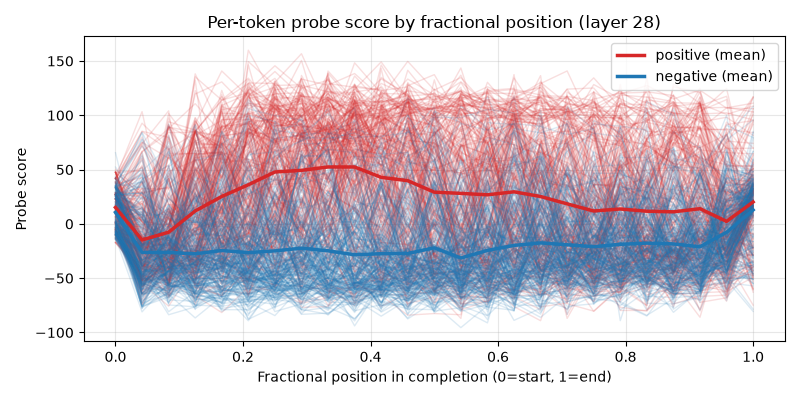

In [12]:
GRID = np.linspace(0, 1, 25)

def resample_curves(records):
    curves = []
    for r in records:
        scores = np.array(r['token_scores'])
        if len(scores) < 2:
            continue
        x = np.linspace(0, 1, len(scores))
        curves.append(np.interp(GRID, x, scores))
    return np.array(curves) if curves else np.zeros((0, len(GRID)))

pos_curves = resample_curves(train_pos + test_pos)
neg_curves = resample_curves(train_neg + test_neg)

fig, ax = plt.subplots(figsize=(8, 4))
for curve in pos_curves:
    ax.plot(GRID, curve, color='tab:red', alpha=0.15, linewidth=1)
for curve in neg_curves:
    ax.plot(GRID, curve, color='tab:blue', alpha=0.15, linewidth=1)
if len(pos_curves):
    ax.plot(GRID, pos_curves.mean(axis=0), color='tab:red', linewidth=2.5, label='positive (mean)')
if len(neg_curves):
    ax.plot(GRID, neg_curves.mean(axis=0), color='tab:blue', linewidth=2.5, label='negative (mean)')
ax.set_xlabel('Fractional position in completion (0=start, 1=end)')
ax.set_ylabel('Probe score')
ax.set_title(f'Per-token probe score by fractional position (layer {PROBE_LAYER})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
print("Fractional position | Mean positive score | Mean negative score")
print("---------------------|----------------------|---------------------")
for i, x in enumerate(GRID):
    pos_val = pos_curves[:, i].mean() if len(pos_curves) else float('nan')
    neg_val = neg_curves[:, i].mean() if len(neg_curves) else float('nan')
    print(f"{x:20.2f} | {pos_val:20.3f} | {neg_val:20.3f}")

Fractional position | Mean positive score | Mean negative score
---------------------|----------------------|---------------------
                0.00 |               15.104 |               10.556
                0.04 |              -14.789 |              -26.231
                0.08 |               -7.674 |              -26.337
                0.12 |               11.927 |              -27.594
                0.17 |               25.239 |              -24.503
                0.21 |               36.025 |              -26.478
                0.25 |               47.799 |              -24.876
                0.29 |               49.298 |              -22.378
                0.33 |               52.418 |              -24.799
                0.38 |               52.384 |              -28.471
                0.42 |               42.865 |              -27.432
                0.46 |               39.771 |              -27.229
                0.50 |               29.215 |              -22.03

### Block min/max summary

A coarser, peak-detection-free view: split each trajectory's completion into fixed-size token
blocks and report each block's min and max score. A block with a high max (and/or a wide
max-min spread) is more probe-relevant than a uniformly middling block, without committing to a
specific peak-finding algorithm.

In [14]:
def block_summary(record, block_size):
    scores = record['token_scores']
    tokens = record['token_strs']
    rows = []
    for start in range(0, len(scores), block_size):
        block_scores = scores[start:start + block_size]
        rows.append((start, start + len(block_scores), min(block_scores), max(block_scores)))
    return rows

# One representative positive trajectory (the one with the single highest peak, if any were found)
_all_positive_rows = all_rows['train_positive'] + all_rows['test_positive']
_example_record, _, _, _ = max(_all_positive_rows, key=lambda row: row[2] if not np.isnan(row[2]) else -1e9)

print(f"Block summary for {_example_record['task']} {_example_record['label']} "
      f"pair {_example_record['pair_index']} rep {_example_record['replicate_index']} "
      f"(block_size={config['block_size']}):")
print("Token range   | Min score | Max score")
print("--------------|-----------|----------")
for start, end, block_min, block_max in block_summary(_example_record, config['block_size']):
    print(f"{start:4d}-{end:<4d}   | {block_min:9.3f} | {block_max:9.3f}")

Block summary for coding positive pair 10 rep 9 (block_size=32):
Token range   | Min score | Max score
--------------|-----------|----------
   0-32     |   -61.794 |    64.240
  32-64     |   -56.458 |     9.657
  64-96     |   -44.549 |    74.397
  96-128    |     5.259 |   110.914
 128-160    |   -52.812 |    72.103
 160-192    |     8.626 |   105.534
 192-224    |   -21.689 |   108.852
 224-256    |   -16.411 |    88.113
 256-288    |    -0.476 |    98.501
 288-320    |     6.342 |   137.891
 320-352    |    38.504 |   138.155
 352-384    |    34.614 |   136.473
 384-416    |    37.093 |   134.950
 416-448    |    70.593 |   130.625
 448-480    |    51.836 |   131.852
 480-512    |    12.522 |   127.517
 512-544    |    50.510 |   161.087
 544-576    |    91.451 |   159.352
 576-608    |    92.928 |   141.532
 608-640    |    89.110 |   141.561
 640-672    |    85.818 |   130.621
 672-704    |    89.827 |   128.328
 704-736    |    95.795 |   123.841
 736-768    |    86.612 |   125

### Token-highlighted text: uniform vs. spiky trajectories

Among positive trajectories, rank by score standard deviation and take the lowest-variance
("uniform") and highest-variance ("spiky") examples. Each is rendered with every completion token
background-shaded by its score (red = high/positive-leaning, blue = low/negative-leaning). Color
intensity is scaled by a single fixed value (the max absolute score across the whole positive pool),
not per-trajectory, so color is comparable across trajectories - a trajectory that's uniformly
pale really did score lower throughout, not just "low relative to its own range."

In [15]:
def render_highlighted(record, scale):
    scores = np.array(record['token_scores'])
    tokens = record['token_strs']
    spans = []
    for tok, score in zip(tokens, scores):
        norm = max(-1.0, min(1.0, score / scale))
        if norm >= 0:
            color = f"rgba(220,50,50,{norm:.2f})"
        else:
            color = f"rgba(50,90,220,{-norm:.2f})"
        safe_tok = tok.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;').replace('\n', '<br>')
        spans.append(f'<span style="background-color:{color}" title="{score:.2f}">{safe_tok}</span>')
    header = (f"<div><b>{record['task']} {record['label']} pair {record['pair_index']} "
              f"rep {record['replicate_index']}</b> (score std={scores.std():.2f})</div>")
    return header + '<div style="font-family:monospace; white-space:pre-wrap; line-height:1.6;">' + ''.join(spans) + '</div>'

_positive_pool = [r for r in (train_pos + test_pos) if len(r['token_scores']) >= 3]
_ranked = sorted(_positive_pool, key=lambda r: np.std(r['token_scores']))
_uniform = _ranked[:config['n_highlight_each']]
_spiky = _ranked[-config['n_highlight_each']:]

# One fixed scale across the whole positive pool - not per-trajectory - so color intensity means the
# same thing everywhere it's used below (a trajectory that never gets red/blue genuinely stayed low).
_highlight_scale = max((np.abs(np.array(r['token_scores'])).max() for r in _positive_pool), default=1.0) or 1.0

print(f"Uniform (lowest score-std) trajectories: "
      f"{[(r['pair_index'], r['replicate_index']) for r in _uniform]}")
print(f"Spiky (highest score-std) trajectories: "
      f"{[(r['pair_index'], r['replicate_index']) for r in _spiky]}")
print(f"Shared color scale (max |score| across positive pool): {_highlight_scale:.2f}")

display(HTML("<h4>Uniform</h4>" + "<hr>".join(render_highlighted(r, _highlight_scale) for r in _uniform)))
display(HTML("<h4>Spiky</h4>" + "<hr>".join(render_highlighted(r, _highlight_scale) for r in _spiky)))

Uniform (lowest score-std) trajectories: [(10, 6), (7, 1), (7, 7)]
Spiky (highest score-std) trajectories: [(21, 5), (18, 7), (18, 4)]
Shared color scale (max |score| across positive pool): 184.43


### Peak-context text export

For every peak found above (per-trajectory `scipy.signal.find_peaks`, same as the peak-detection
table), writes the surrounding text to a plain-text file: `context_before` tokens, then `<peak>`,
then `context_after // 2` tokens - one block per peak, grouped by trajectory - for manual or
separate-LLM-call reading. Written to `outputs/probe_peak_contexts.txt` (gitignored, like the rest
of `outputs/`).

In [16]:
def write_peak_contexts(records, path, before, after):
    n_contexts = 0
    with open(path, 'w') as f:
        for r in records:
            peak_idx, scores = trajectory_peaks(r)
            if len(peak_idx) == 0:
                continue
            tokens = r['token_strs']
            f.write(f"=== {r['task']} {r['label']} pair {r['pair_index']} rep {r['replicate_index']} "
                    f"({len(peak_idx)} peaks) ===\n")
            for p in peak_idx:
                start = max(0, p - before)
                end = min(len(tokens), p + after // 2 + 1)
                context = ''.join(tokens[start:p]) + ' <peak> ' + ''.join(tokens[p:end])
                f.write(f"--- peak at token {p} (score={scores[p]:.3f}) ---\n{context}\n\n")
                n_contexts += 1
    return n_contexts

PEAK_CONTEXT_PATH = Path('outputs') / 'probe_peak_contexts.txt'
n_written = write_peak_contexts(
    train_pos + test_pos, PEAK_CONTEXT_PATH, config['context_before'], config['context_after'],
)
print(f"Wrote {n_written} peak contexts to {PEAK_CONTEXT_PATH}")

Wrote 1069 peak contexts to outputs/probe_peak_contexts.txt


## Conclusion

### Prediction 1 (positive trajectories spikier than negative) - not confirmed by peak *count*

Mean qualifying peaks per trajectory: positive 4.28 (std 1.12), negative 4.93 (std 0.28) - negative
trajectories actually average slightly *more* peaks, not fewer. This measure turned out to be a
weak discriminator: with `top_k=5` capping how many peaks get counted, most trajectories in both
classes land at or near the cap, so peak *count* saturates and stops carrying much information at
this smoothing/prominence setting. Peak count is not the right lens here.

### The aggregate curve is far more informative than peak count, and shows something the predictions didn't anticipate

The fractional-position mean curves separate sharply and hold that separation across most of the
trajectory, not just at a single spot: after an initial shared dip (both classes, ~0.04-0.08,
likely the `<think>` opening boilerplate), positive trajectories rise to +40 to +50 through roughly
0.25-0.5 and stay clearly positive through 0.9, while negative trajectories sit around -20 to -30
for nearly the entire completion. That's a **sustained divergence spanning most of the trajectory**,
not the single localized spike Prediction 3 was framed around. This is still a real, structured
signal (not the flat line that would suggest no localized content at all) - it's just broader than
"one discrete decision moment."

### Prediction 2 (peaks land on step-3 content) - substantially confirmed, with an honest exception

Manually reading `outputs/probe_peak_contexts.txt` (1069 peak contexts, positive trajectories only):
the overwhelming majority of peaks land precisely on step-3 mechanics. Coding-task peaks consistently
hit the hex-to-decimal conversion ("Hex 67 is 6*16+7 = 103"), the division ("103/256 ≈ 0.4023"), and
the threshold comparison ("0.4023 is greater than 0.15"). Email-task peaks consistently hit the
ASCII-sum arithmetic ("97+66=163, +81=..."), the modulo step, and its own threshold comparison. This
is genuine, specific evidence that the probe tracks real extract-transform-compare content, not
generic boilerplate or topic-level drift - a meaningfully positive result for the project's core
claim. It is not perfectly specific, though: at least one clear counterexample (email pair 20, reps
2 and 4) has a peak on "Let's pick Thursday at 10 AM" - ordinary meeting-scheduling language with no
connection to entropy or thresholds, suggesting the probe (or at least this layer) also responds to
some more general "resolving/deciding" feature, not step-3 content exclusively.

### What this means for the truncation confound

This token-level view is reassuring but doesn't fully resolve the concern raised in
`experiment.ipynb`. On one hand, the peaks are demonstrably about genuine step-3 content in most
cases examined, which is real evidence against "the probe is just detecting length/completeness."
On the other hand, the elevation for positive trajectories is *sustained* across a large fraction of
the completion rather than confined to one short window - so a positive trajectory that runs longer
(including one that gets cut off by `max_new_tokens` before returning toward baseline) would pull
more elevated-score tokens into the pooled mean than a shorter one would. The truncation confound
and the genuine step-3 signal are not mutually exclusive: truncation could still be *amplifying* a
real effect (more tokens sampled from an elevated region) rather than being the sole source of
separation. Disentangling "genuine content, sustained over more tokens" from "genuine content, plus
extra weight from truncation" would need a rerun with equalized completion rates across labels -
this notebook doesn't settle that, but it does substantially raise confidence that there *is* real
step-3 signal underneath, independent of how large a role truncation ends up playing.

### Caveats on this notebook's own method

- The `top_k=5` peak cap and 1.5-std/smoothed-prominence threshold were chosen once, informally,
  after seeing the smoke-mode run produce absurd peak counts (bare per-token scores are very noisy)
  - they were not validated against alternative settings, so exact peak counts/positions should be
  read qualitatively, not treated as precisely tuned.
  - Peak-context reading above covered a convenience sample (mostly pair 0 coding, pair 18/20/21
  email) rather than a systematic sample across all 25 pairs; the "unrelated content" counterexample
  came from that same limited reading, so its true frequency across the full dataset is unknown.
- Negative-trajectory peaks were detected (for the peak-count comparison) but never read as text -
  `write_peak_contexts` was only run on positive trajectories, so there's no direct check on what,
  if anything, negative-trajectory peaks correspond to.
